In [47]:
import numpy as np
import pandas as pd
import torch 
import cv2
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import os
import h5py
import pims
from tqdm import tqdm
from torchvision.io import read_video
import gc

In [48]:
VIDEO_BASE_PATH = r"E:\nexar_dataset\train"
OUTPUT_PATH = r"E:\nexar_dataset\new_frames"

meta_pos = pd.read_csv(r"E:\nexar_dataset\metadata1.csv")
meta_neg = pd.read_csv(r"E:\nexar_dataset\metadata2.csv")

meta_pos["target"] = 1
meta_neg["target"] = 0

train = pd.concat([meta_pos, meta_neg], ignore_index=True)


In [49]:

train["video_path"] = train.apply(
    lambda row: os.path.join(
        VIDEO_BASE_PATH,
        "positive" if row["target"] == 1 else "negative",
        row["file_name"]
    ),
    axis=1
)

train["id"] = range(len(train))

print(" shape:", train.shape)
print(train.head())


 shape: (1500, 10)
   file_name  time_of_event  time_of_alert light_conditions weather  \
0  00822.mp4         19.500         18.633           Normal  Cloudy   
1  00208.mp4         19.800         19.233           Normal  Cloudy   
2  00072.mp4         20.101         20.068           Normal   Clear   
3  00128.mp4         19.267         18.333           Normal   Clear   
4  00205.mp4         21.146         18.196           Normal   Clear   

       scene  time_to_accident  target  \
0      Urban               NaN       1   
1  Sub-urban               NaN       1   
2      Urban               NaN       1   
3      Urban               NaN       1   
4    Highway               NaN       1   

                                  video_path  id  
0  E:\nexar_dataset\train\positive\00822.mp4   0  
1  E:\nexar_dataset\train\positive\00208.mp4   1  
2  E:\nexar_dataset\train\positive\00072.mp4   2  
3  E:\nexar_dataset\train\positive\00128.mp4   3  
4  E:\nexar_dataset\train\positive\00205.mp4  

In [5]:
len(train)

1500

In [ ]:
pip install imageio imageio-ffmpeg


In [5]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [50]:
def get_frame_count(sample):
    cap = cv2.VideoCapture(sample["video_path"])
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return total_frames

def get_fps(sample):
    cap = cv2.VideoCapture(sample["video_path"])
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return fps

train["total_frame"] = train.apply(get_frame_count, axis=1)
train["fps"] = train.apply(get_fps, axis=1)
df = train[(train["fps"] > 0) & (train["total_frame"] > 0)]

print(f" Valid videos after filtering: {len(df)}")

 Valid videos after filtering: 1500


In [51]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df , test_size=0.2, stratify=train["target"], random_state=42)
print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}")

Train size: 1200, Validation size: 300


In [52]:

def get_frames_and_save(df , num_frames, output_path):
    os.makedirs(output_path, exist_ok=True)
    
    for i in range(df.shape[0]):
        sample = df.iloc[i]
        path = sample["video_path"]
        
        try:
            video = pims.Video(path)
        except Exception as e:
            print(f"Error opening {os.path.basename(path)}: {e}")
            continue

        fps = sample["fps"]
        total_time = int(sample["total_frame"] / fps) if fps > 0 else 0

        if sample["target"] == 1:
            alert_time = sample.get("time_of_alert", 0) or 0
            event_time = sample.get("time_of_event", 0) or 0
            start_time = max(0, alert_time - 2)
            end_time = min(total_time, event_time + 2)
        else:
            mid_time = int(total_time) // 2
            start_time = max(0, mid_time - 5)
            end_time = min(total_time, mid_time + 5)

        start_frame = int(fps * start_time)
        end_frame = int(fps * end_time)
        step = max((end_frame - start_frame) // num_frames, 1)

        frames = []
        #print(f"\n Extracting frames from {os.path.basename(path)}")

        for frame_idx in range(start_frame, end_frame + 1, step):
            try:
                frame = video[int(frame_idx)]
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame_resized = cv2.resize(frame, (224, 224))
                frame_resized = frame_resized.astype("float32") / 255.0
                frame_tensor = torch.tensor(frame_resized).permute(2, 0, 1)
                frames.append(frame_tensor)
            except Exception :
                continue

        if len(frames) == 0:
            print(f"No valid frames in {os.path.basename(path)}")
            continue

        frames_np = torch.stack(frames).numpy()
        np.save(os.path.join(output_path, str(int(sample["id"]))), frames_np)




In [53]:

def validation_video(video_path, end_time, fps, num_frames=32):
    start_second = 0
    end_second = end_time
    start_frame = int(start_second * fps)
    end_frame = int(end_second * fps)
    total_frames = end_frame - start_frame
    video = pims.Video(video_path)
    
    if total_frames >= num_frames:
        indices = np.linspace(start_frame, end_frame - 1, num_frames).astype(int)
    else:
        indices = list(range(start_frame, end_frame))
        while len(indices) < num_frames:
            indices.append(end_frame - 1)
    
    frames = []
    for idx in indices:
        frame = np.array(video[idx])
        frame = cv2.resize(frame, (224, 224))
        if frame.ndim == 2:
            frame = np.stack([frame]*3, axis=-1)
        frames.append(frame.astype(np.uint8))
    return frames


In [ ]:

NUM_FRAMES_TRAIN = 32
NUM_FRAMES_VAL = 32
BATCH_SIZE = 100

train_output = os.path.join(OUTPUT_PATH, "train")
val_output = os.path.join(OUTPUT_PATH, "val")
os.makedirs(train_output, exist_ok=True)
os.makedirs(val_output, exist_ok=True)

print("\n Processing TRAIN videos...\n")
total_batches = (len(train_df) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_idx, start in enumerate(range(0, len(train_df), BATCH_SIZE), start=1):
    end = min(start + BATCH_SIZE, len(train_df))
    batch = train_df.iloc[start:end]

    print(f"📦 Batch {batch_idx}/{total_batches} | videos {start} to {end-1}")

    for _, row in tqdm(batch.iterrows(), total=len(batch), desc=f"🔹Processing Batch {batch_idx}", ncols=100):
        sample_df = pd.DataFrame([row])
        try:
            get_frames_and_save(sample_df, num_frames=NUM_FRAMES_TRAIN, output_path=train_output)
        except Exception as e:
            print(f"Error in video {os.path.basename(row['video_path'])}: {e}")
            continue

    gc.collect()

print("\n All TRAIN videos processed and saved successfully!\n")


#  VALIDATION 

print("\n Processing VALIDATION videos...\n")
total_batches_val = (len(val_df) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_idx, start in enumerate(range(0, len(val_df), BATCH_SIZE), start=1):
    end = min(start + BATCH_SIZE, len(val_df))
    batch = val_df.iloc[start:end]

    print(f"📦 Batch {batch_idx}/{total_batches_val} | videos {start} to {end-1}")

    for _, row in tqdm(batch.iterrows(), total=len(batch), desc=f"🔹Processing Batch {batch_idx}", ncols=100):
        try:
            frames = validation_video(
                video_path=row["video_path"],
                end_time=row["total_frame"] / row["fps"],
                fps=row["fps"],
                num_frames=NUM_FRAMES_VAL
            )
            np.save(os.path.join(val_output, f"{int(row['id'])}"), np.array(frames))
        except Exception as e:
            print(f" Error in video {os.path.basename(row['video_path'])}: {e}")
            continue

    gc.collect()

print("\n All VALIDATION videos processed and saved successfully!\n")


 Processing TRAIN videos...

📦 Batch 1/12 | videos 0 to 99


🔹Processing Batch 1:   0%|                                                 | 0/100 [00:00<?, ?it/s]

🔹Processing Batch 1: 100%|███████████████████████████████████████| 100/100 [04:02<00:00,  2.42s/it]


📦 Batch 2/12 | videos 100 to 199


🔹Processing Batch 2: 100%|███████████████████████████████████████| 100/100 [03:29<00:00,  2.09s/it]


...

📦 Batch 2/3 | videos 100 to 199


🔹Processing Batch 2: 100%|████████████████████████████████████| 100/100 [5:18:47<00:00, 191.28s/it]


📦 Batch 3/3 | videos 200 to 299


🔹Processing Batch 3: 100%|█████████████████████████████████████| 100/100 [1:45:35<00:00, 63.36s/it]



 All VALIDATION videos processed and saved successfully!



some files: ['0.npy', '1.npy', '10.npy', '100.npy', '1000.npy']
 array shape (11, 3, 224, 224)
 type: float32


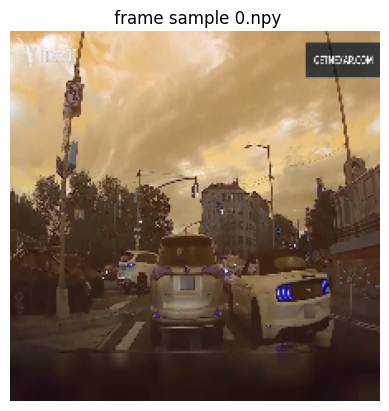

In [ ]:

files = [f for f in os.listdir(OUTPUT_PATH) if f.endswith(".npy")]
print("some files:", files[:5])

sample_path = os.path.join(OUTPUT_PATH, files[0])
frames = np.load(sample_path)

print(" array shape", frames.shape)
print(" type:", frames.dtype)

frame = frames[0] 
frame_rgb = np.transpose(frame, (1, 2, 0))  # turn to (224, 224, 3)

plt.imshow(frame_rgb)
plt.title(f" frame sample {files[0]}")
plt.axis("off")
plt.show()

In [54]:
from torch.utils.data import Dataset, DataLoader

class CrashFrameDataset(Dataset):
    def __init__(self, df, frames_dir, num_frames=32):
        self.df = df.reset_index(drop=True)
        self.frames_dir = frames_dir
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        video_id = int(sample["id"])
        target = int(sample["target"])

        npy_path = os.path.join(self.frames_dir, f"{video_id}.npy")
        frames = np.load(npy_path)  
        #Fix wrong shape (if channels last)
        if frames.ndim == 4 and frames.shape[-1] == 3:
            frames = np.transpose(frames, (0, 3, 1, 2))  # (T, 3, H, W)
        assert frames.shape[1] == 3, f"Expected 3 channels, got {frames.shape}"


        # normalize to fixed length 
        T = frames.shape[0]
        if T > self.num_frames:  
            idxs = np.linspace(0, T-1, self.num_frames).astype(int)
            frames = frames[idxs]
        elif T < self.num_frames:  # pad by repeating last frame
            last = frames[-1][None, ...]
            pad = np.repeat(last, self.num_frames - T, axis=0)
            frames = np.concatenate([frames, pad], axis=0)

        frames = torch.tensor(frames, dtype=torch.float32)
        label = torch.tensor(target, dtype=torch.long)
        return frames, label
    
TRAIN_FRAMES_PATH = r"E:\nexar_dataset\new_frames\train"
VAL_FRAMES_PATH   = r"E:\nexar_dataset\new_frames\val"

train_dataset = CrashFrameDataset(train_df, TRAIN_FRAMES_PATH)
val_dataset   = CrashFrameDataset(val_df, VAL_FRAMES_PATH)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f" Train videos: {len(train_dataset)}, Validation videos: {len(val_dataset)}")

 Train videos: 1200, Validation videos: 300


In [55]:
frames, labels = next(iter(train_loader))
print("Frames shape:", frames.shape)


Frames shape: torch.Size([1, 32, 3, 224, 224])


In [56]:
import torch.nn as nn
import torchvision.models as models

class CrashDetectionModel(nn.Module):
    def __init__(self, num_classes=2, hidden_size=256):
        super(CrashDetectionModel, self).__init__()

        # EfficientNet feature extractor
        self.feature_extractor = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        
        self.feature_extractor.classifier = nn.Identity()
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))        # explicit global pooling 


        # Fine-tune only the last 20 layers of EfficientNet
        for name, param in self.feature_extractor.features.named_parameters():
            param.requires_grad = False # Freeze all first

        # Unfreeze last N parameters 
        for name, param in list(self.feature_extractor.features.named_parameters())[-20:]:
            param.requires_grad = True

        
        # Projection before LSTM
        self.pre_lstm = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, T, 3, 224, 224)
        B, T, C, H, W = x.shape
        x = x.contiguous().view(B * T, C, H, W)
        feats = self.feature_extractor.features(x)  
        feats = self.global_pool(feats).squeeze(-1).squeeze(-1)
        feats = feats.view(B, T, 1280)  #(B, T, feature_dim)
        feats = self.pre_lstm(feats)  # Linear before LSTM(B, T, 512)

        # LSTM
        lstm_out, _ = self.lstm(feats)  # (B, T, hidden_size)
        last_output = lstm_out[:, -1, :]  # (B, hidden_size)

        # Classifier
        out = self.classifier(last_output)
        return out

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrashDetectionModel().to(device)

frames, labels = next(iter(train_loader))

frames = frames.to(device)
labels = torch.tensor(labels, dtype=torch.long).to(device)

outputs = model(frames)
print("Output shape:", outputs.shape)

print(" Batch shape:", frames.shape)


Output shape: torch.Size([1, 2])
 Batch shape: torch.Size([1, 32, 3, 224, 224])


C:\Users\Asus\AppData\Local\Temp\ipykernel_16064\3936537951.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long).to(device)


In [58]:
trainable = sum(p.requires_grad for p in model.feature_extractor.parameters())
frozen = sum(not p.requires_grad for p in model.feature_extractor.parameters())
print(f"Trainable params: {trainable}, Frozen params: {frozen}")

Trainable params: 20, Frozen params: 191


In [59]:

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())


CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU
Current device index: 0


In [60]:
gc.collect()
torch.cuda.empty_cache()

In [61]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [62]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CrashDetectionModel().to(device)
rames = frames.to(device)
labels = torch.tensor(labels, dtype=torch.long).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 30
patience = 5 
counter = 0
best_val_loss = float('inf')


for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for frames, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", ncols=100):
        frames = frames.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        torch.cuda.empty_cache()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

# VALIDATION 
    model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for frames, labels in tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", ncols=100):
            frames = frames.to(device)
            labels = labels.to(device).long()

            outputs = model(frames)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)


    print(f" Epoch {epoch+1}/{num_epochs} | "  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "  f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")


    #Early Stopping 
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("-> Validation loss improved — model saved.")
    else:
        counter += 1
        print(f" No improvement for {counter} epochs.")
        if counter >= patience:
            print(" Early stopping triggered.")
            break


C:\Users\Asus\AppData\Local\Temp\ipykernel_16064\4119533131.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long).to(device)



 Epoch 1/30


Validating Epoch 1: 100%|█████████████████████████████████████████| 300/300 [00:23<00:00, 12.53it/s]


 Epoch 1/30 | Train Loss: 0.6878 | Train Acc: 0.5367 | Val Loss: 0.6941 | Val Acc: 0.5000
-> Validation loss improved — model saved.

 Epoch 2/30


Validating Epoch 2: 100%|█████████████████████████████████████████| 300/300 [00:19<00:00, 15.36it/s]


...

 Epoch 4/30 | Train Loss: 0.2108 | Train Acc: 0.9217 | Val Loss: 1.7335 | Val Acc: 0.5133
 No improvement for 3 epochs.

 Epoch 5/30


Validating Epoch 5: 100%|█████████████████████████████████████████| 300/300 [00:32<00:00,  9.21it/s]


 Epoch 5/30 | Train Loss: 0.1195 | Train Acc: 0.9583 | Val Loss: 2.0852 | Val Acc: 0.4733
 No improvement for 4 epochs.

 Epoch 6/30


Validating Epoch 6: 100%|█████████████████████████████████████████| 300/300 [00:32<00:00,  9.36it/s]

 Epoch 6/30 | Train Loss: 0.0661 | Train Acc: 0.9775 | Val Loss: 2.5280 | Val Acc: 0.4933
 No improvement for 5 epochs.
 Early stopping triggered.


In [46]:
save_path = r"E:\Group-10-project-2\lstm_model.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc,
    'val_loss': avg_val_loss
}, save_path)

print(f"model saved \n{save_path}")


model saved 
E:\Group-10-project-2\lstm_model.pth


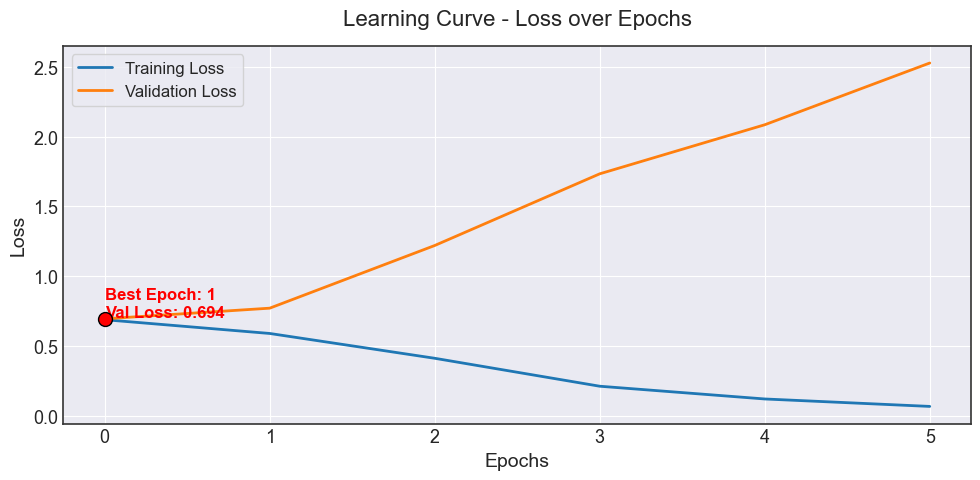

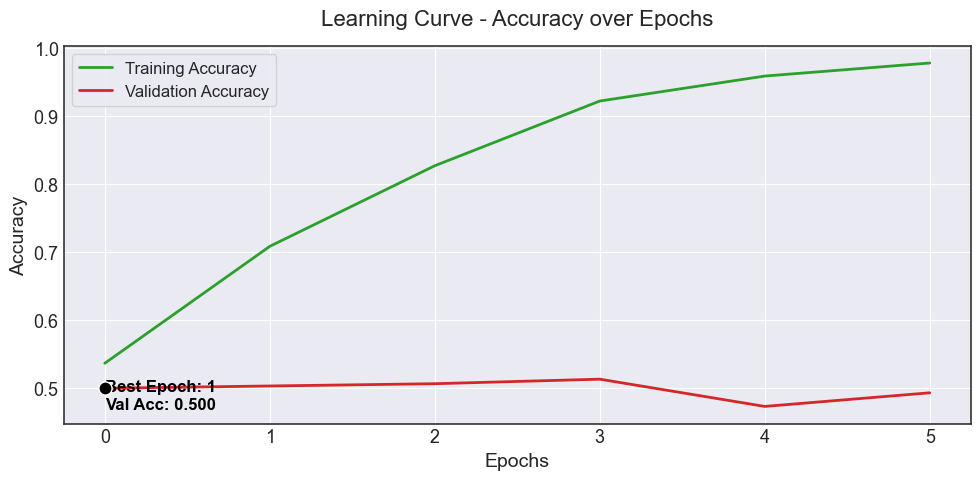

In [65]:

best_epoch = np.argmin(history['val_loss'])
best_val_loss = history['val_loss'][best_epoch]
best_val_acc = history['val_acc'][best_epoch]

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'figure.figsize': (10,5),
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
})

# Loss
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)

plt.scatter(best_epoch, best_val_loss, color='red', s=100, edgecolors='k', zorder=5)
plt.text(best_epoch, best_val_loss + 0.015,
         f'Best Epoch: {best_epoch+1}\nVal Loss: {best_val_loss:.3f}',
         color='red', fontsize=12, fontweight='bold')

plt.title('Learning Curve - Loss over Epochs', pad=15)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history['train_acc'], label='Training Accuracy', color='#2ca02c', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='#d62728', linewidth=2)

plt.scatter(best_epoch, best_val_acc, color='black', s=90, edgecolors='white', zorder=5)
plt.text(best_epoch, best_val_acc - 0.03,
         f'Best Epoch: {best_epoch+1}\nVal Acc: {best_val_acc:.3f}',
         color='black', fontsize=12, fontweight='bold')

plt.title('Learning Curve - Accuracy over Epochs', pad=15)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()



Evaluating for Confusion Matrix: 100%|██████████| 300/300 [00:17<00:00, 16.90it/s]


<Figure size 500x500 with 0 Axes>

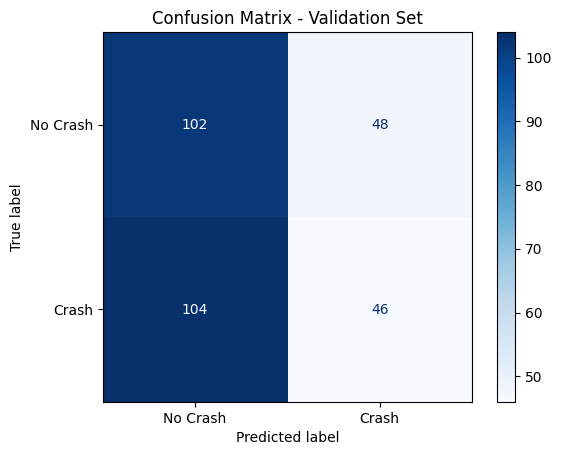

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for frames, labels in tqdm(val_loader, desc="Evaluating for Confusion Matrix"):
        frames = frames.to(device)
        outputs = model(frames)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = labels.numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crash", "Crash"])

plt.figure(figsize=(5,5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Validation Set")
plt.show()
